# Fase 2 — Notebook 1: obtención y exploración inicial de los datos

**Proyecto:** Sobreduración en la titulación de la educación superior chilena (2020–2025)
**Equipo:** «Integrante 1», «Integrante 2», «Integrante 3»  ·  **Grupo:** «N»

---

**Objetivo de este notebook (OE2 y OE3).** Consolidar los seis archivos anuales
del SIES en un único conjunto verificado contra las cifras oficiales, describir
su estructura y distribuciones, y **levantar el inventario de problemas de
calidad** que la limpieza deberá resolver en el notebook siguiente.

Este notebook no modifica los datos: solo los carga y los observa. Toda
corrección se realiza en `F2_2_Limpieza_Transformacion.ipynb`, de modo que el
diagnóstico quede separado del tratamiento.

## 1. Entorno de ejecución

In [1]:
# Celda de arranque: hace importable el paquete `src` sin instalar el proyecto
# y funciona igual si el notebook se abre desde la raiz o desde su subcarpeta.
import sys
from pathlib import Path

RAIZ = Path.cwd()
if not (RAIZ / "src").exists():
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ))

import pandas as pd

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

from src import config

print("Raiz del proyecto:", RAIZ)
for clave, valor in config.describir_entorno().items():
    print(f"  {clave:12s} {valor}")

Raiz del proyecto: D:\IA Development\proyecto-titulados


  python       3.14.7
  plataforma   Windows-11-10.0.26200-SP0
  ejecutable   D:\IA Development\proyecto-titulados\.venv\Scripts\python.exe
  numpy        2.5.3
  pandas       3.0.5
  matplotlib   3.11.1
  seaborn      0.13.2
  pyarrow      25.0.1


## 2. Obtención y consolidación

Los seis CSV suman ~955 MB, un volumen que hace inviable la lectura ingenua con
`pd.read_csv` sobre el archivo completo. La estrategia implementada en
`src/ingesta.py` es:

1. **Lectura por bloques** de 200.000 filas (`chunksize`), de modo que la memoria
   ocupada no depende del tamaño del archivo.
2. **Lectura como texto** y conversión posterior controlada: si un valor no es
   convertible, se registra como coerción en lugar de abortar la carga completa.
3. **Selección de columnas** (`usecols`): 30 de las 40 originales, según el
   esquema declarado en `src/config.py`.
4. **Persistencia en Parquet**, formato columnar y comprimido que conserva los
   tipos y evita volver a parsear texto en cada ejecución.

In [2]:
from src import ingesta

import time

inicio = time.perf_counter()

if config.PARQUET_CONSOLIDADO.exists():
    df = ingesta.cargar_consolidado()
    bitacora_ingesta = None
    print(f"Parquet consolidado existente cargado en {time.perf_counter()-inicio:.1f} s")
else:
    df, bitacora_ingesta = ingesta.consolidar()

print(f"Registros consolidados: {len(df):,}")
print(f"Columnas: {df.shape[1]}")
print(f"Memoria en RAM: {df.memory_usage(deep=True).sum()/1024**2:,.1f} MB")

Parquet consolidado existente cargado en 0.1 s
Registros consolidados: 1,710,167
Columnas: 30
Memoria en RAM: 100.0 MB


### 2.1 Verificación de integridad contra la fuente oficial

El documento de esquema del SIES publica el número exacto de observaciones por
año. Comparar ambos conteos es la prueba de que **no se perdió ni se duplicó
ningún registro** durante la lectura por bloques.

In [3]:
conteo = df["cat_periodo"].value_counts().sort_index()

verificacion = pd.DataFrame({
    "anio": conteo.index.astype(int),
    "filas_cargadas": conteo.to_numpy(),
    "filas_oficiales_sies": [config.FILAS_OFICIALES_SIES[int(a)] for a in conteo.index],
})
verificacion["diferencia"] = (
    verificacion["filas_cargadas"] - verificacion["filas_oficiales_sies"]
)
verificacion["estado"] = verificacion["diferencia"].map(
    lambda d: "OK" if d == 0 else "REVISAR"
)

print(verificacion.to_string(index=False))
assert (verificacion["diferencia"] == 0).all(), "La carga no coincide con la fuente oficial"
print(f"\nIntegridad verificada: {verificacion['filas_cargadas'].sum():,} registros, "
      "coincidencia exacta con las cifras publicadas por el SIES.")

 anio  filas_cargadas  filas_oficiales_sies  diferencia estado
 2020          203598                203598           0     OK
 2021          281491                281491           0     OK
 2022          291460                291460           0     OK
 2023          299893                299893           0     OK
 2024          304727                304727           0     OK
 2025          328998                328998           0     OK

Integridad verificada: 1,710,167 registros, coincidencia exacta con las cifras publicadas por el SIES.


## 3. Estructura del conjunto de datos

In [4]:
estructura = pd.DataFrame({
    "columna": df.columns,
    "tipo": [str(t) for t in df.dtypes],
    "no_nulos": df.notna().sum().to_numpy(),
    "valores_unicos": [df[c].nunique(dropna=True) for c in df.columns],
    "memoria_mb": (df.memory_usage(deep=True)[1:] / 1024**2).round(2).to_numpy(),
})
print(estructura.to_string(index=False))

               columna     tipo  no_nulos  valores_unicos  memoria_mb
           cat_periodo    int16   1710167               6        3.26
                  mrun  float64   1706633         1470466       13.05
               gen_alu     int8   1710167               2        1.63
           fec_nac_alu    int32   1710167             790        6.52
            rango_edad category   1710167               7        1.63
     anio_ing_carr_ori    int32   1710167              58        6.52
      sem_ing_carr_ori     int8   1710167               3        1.63
fecha_obtencion_titulo    int32   1710167            2187        6.52
           tipo_inst_1 category   1710167               3        1.63
           tipo_inst_2 category   1710167               4        1.63
              cod_inst    int16   1710167             148        3.26
             nomb_inst category   1710167             149        3.27
           cod_carrera  float64   1678538            1574       13.05
          nomb_carre

### 3.1 Primeras filas

In [5]:
df.head(5)

,cat_periodo,mrun,gen_alu,fec_nac_alu,rango_edad,anio_ing_carr_ori,sem_ing_carr_ori,fecha_obtencion_titulo,tipo_inst_1,tipo_inst_2,cod_inst,nomb_inst,cod_carrera,nomb_carrera,nivel_global,nivel_carrera_1,nivel_carrera_2,dur_estudio_carr,dur_proceso_tit,dur_total_carr,region_sede,provincia_sede,comuna_sede,jornada,modalidad,tipo_plan_carr,area_conocimiento,area_generica,cine_f_13_area,cine_f_13_subarea
0,2020,59.0,1,199903,20 a 24 Años,2018,1,20210114,Universidades,Universidades CRUCH,81,UNIVERSIDAD ARTURO PRAT,72.0,TECNICO DE NIVEL SUPERIOR TRADUCTOR BILINGÜE I...,Pregrado,Técnico de Nivel Superior,Carreras Técnicas,5,0,5,Arica y Parinacota,ARICA,ARICA,Vespertina,Presencial,Plan Regular,Humanidades,Técnico en Traducción e Interpretariado,Artes y Humanidades,Idiomas
1,2020,190.0,1,199604,20 a 24 Años,2014,1,20200605,Universidades,Universidades CRUCH,70,UNIVERSIDAD DE CHILE,177.0,QUIMICA Y FARMACIA,Pregrado,Profesional Con Licenciatura,Carreras Profesionales,12,0,12,Metropolitana,SANTIAGO,SANTIAGO,Diurna,Presencial,Plan Regular,Salud,Química y Farmacia,Salud y Bienestar,Salud
2,2020,252.0,1,198405,35 a 39 Años,2018,1,20200923,Universidades,Universidades CRUCH,94,UNIVERSIDAD CATOLICA DE TEMUCO,273.0,MAGISTER EN ANTROPOLOGIA,Posgrado,Magister,Magister,4,0,4,La Araucanía,CAUTIN,TEMUCO,Semipresencial,Semipresencial,Plan Regular,Ciencias Sociales,Magister en Ciencias Sociales,"Ciencias Sociales, Periodismo e Información",Ciencias Sociales y del Comportamiento
3,2020,393.0,1,199409,25 a 29 Años,2018,1,20200422,Centros de Formación Técnica,Centros de Formación Técnica,260,CFT SANTO TOMAS,43.0,TECNICO AGRICOLA,Pregrado,Técnico de Nivel Superior,Carreras Técnicas,5,0,5,Maule,CURICO,CURICO,Vespertina,Presencial,Plan Regular,Agropecuaria,Técnico Agropecuario,"Agricultura, Silvicultura, Pesca y Veterinaria",Agricultura
4,2020,398.0,2,199604,20 a 24 Años,2016,1,20210216,Universidades,Universidades Privadas,54,UNIVERSIDAD TECNOLOGICA DE CHILE INACAP,68.0,INGENIERIA EN ADMINISTRACION DE EMPRESAS MENCI...,Pregrado,Profesional Sin Licenciatura,Carreras Profesionales,8,0,8,Valparaíso,VALPARAISO,VALPARAISO,Vespertina,Presencial,Plan Regular,Administración y Comercio,Administración de Empresas e Ing. Asociadas,Administración de Empresas y Derecho,Educación Comercial y Administración


### 3.2 Diccionario de variables

Definiciones tomadas del esquema de registro oficial del SIES (secciones 1.2 y
Anexo I). Se documentan aquí para que el notebook sea autocontenido.

In [6]:
diccionario = pd.DataFrame(
    [
        ("cat_periodo", "Año académico del proceso de titulación", "2020-2025"),
        ("mrun", "Identificador anonimizado del estudiante", "entero"),
        ("gen_alu", "Sexo del estudiante", "1: Hombre; 2: Mujer"),
        ("fec_nac_alu", "Fecha de nacimiento (AAAAMM)", "190001 = sin información"),
        ("anio_ing_carr_ori", "Año de ingreso a la carrera de origen",
         "9995/9998/9999/1900 = códigos especiales"),
        ("sem_ing_carr_ori", "Semestre de ingreso a la carrera de origen", "1 o 2"),
        ("fecha_obtencion_titulo", "Fecha de obtención del título (AAAAMMDD)",
         "19000101 = sin información"),
        ("tipo_inst_1", "Tipo de institución", "Universidad / IP / CFT"),
        ("nivel_global", "Nivel del programa", "Pregrado / Postgrado / Postítulo"),
        ("dur_estudio_carr", "Duración TEÓRICA de estudios del plan (semestres)", "entero"),
        ("dur_proceso_tit", "Duración TEÓRICA del proceso de titulación (semestres)", "entero"),
        ("dur_total_carr", "Duración TEÓRICA total del plan (semestres)", "entero"),
        ("region_sede", "Región donde se imparte la carrera", "16 regiones"),
        ("jornada", "Jornada del programa", "Diurna/Vespertina/A distancia/..."),
        ("modalidad", "Modalidad de impartición", "Presencial/Semipresencial/No presencial"),
        ("area_conocimiento", "Área MINEDUC (adaptación CINE-UNESCO 1997)", "10 áreas"),
        ("cine_f_13_area", "Área CINE-F 2013 (UNESCO/OCDE)", "clasificación internacional"),
    ],
    columns=["variable", "descripción", "valores"],
)
print(diccionario.to_string(index=False))

              variable                                            descripción                                  valores
           cat_periodo                Año académico del proceso de titulación                                2020-2025
                  mrun               Identificador anonimizado del estudiante                                   entero
               gen_alu                                    Sexo del estudiante                      1: Hombre; 2: Mujer
           fec_nac_alu                           Fecha de nacimiento (AAAAMM)                 190001 = sin información
     anio_ing_carr_ori                  Año de ingreso a la carrera de origen 9995/9998/9999/1900 = códigos especiales
      sem_ing_carr_ori             Semestre de ingreso a la carrera de origen                                    1 o 2
fecha_obtencion_titulo               Fecha de obtención del título (AAAAMMDD)               19000101 = sin información
           tipo_inst_1                          

> **Advertencia metodológica central.** Las tres variables `dur_*` son
> **duraciones teóricas del plan de estudios**, no el tiempo que tardó el
> estudiante. El dato de trayectoria real **no existe en la base**: debe
> reconstruirse a partir del año y semestre de ingreso y de la fecha del
> título. Esa reconstrucción es la contribución técnica de la Fase 2 y se
> desarrolla en el notebook siguiente.

## 4. Estadísticos descriptivos

In [7]:
numericas = ["dur_estudio_carr", "dur_proceso_tit", "dur_total_carr",
             "anio_ing_carr_ori", "sem_ing_carr_ori", "gen_alu"]
df[numericas].describe().round(2)

,dur_estudio_carr,dur_proceso_tit,dur_total_carr,anio_ing_carr_ori,sem_ing_carr_ori,gen_alu
count,1710167.00,1710167.00,1710167.00,1710167.00,1710167.00,1710167.00
mean,6.11,0.41,6.16,2014.79,1.04,1.56
std,3.18,0.57,3.18,22.59,0.33,0.50
min,1.00,0.00,1.00,1900.00,0.00,1.00
25%,4.00,0.00,4.00,2017.00,1.00,1.00
50%,5.00,0.00,5.00,2019.00,1.00,2.00
75%,9.00,1.00,9.00,2021.00,1.00,2.00
max,24.00,9.00,24.00,2025.00,2.00,2.00


### 4.1 Distribución de las variables categóricas principales

In [8]:
for columna in ["nivel_global", "tipo_inst_1", "modalidad", "jornada"]:
    conteo = df[columna].value_counts()
    porcentaje = (100 * conteo / len(df)).round(1)
    resumen = pd.DataFrame({"registros": conteo, "porcentaje": porcentaje})
    print(f"--- {columna} ---")
    print(resumen.to_string())
    print()

--- nivel_global ---
              registros  porcentaje
nivel_global                       
Pregrado        1311776        76.7
Postítulo        278187        16.3
Posgrado         120204         7.0

--- tipo_inst_1 ---
                              registros  porcentaje
tipo_inst_1                                        
Universidades                   1011229        59.1
Institutos Profesionales         482517        28.2
Centros de Formación Técnica     216421        12.7

--- modalidad ---
                registros  porcentaje
modalidad                            
Presencial        1355168        79.2
No Presencial      284544        16.6
Semipresencial      70455         4.1

--- jornada ---
                registros  porcentaje
jornada                              
Diurna             924427        54.1
Vespertina         421470        24.6
A Distancia        284544        16.6
Semipresencial      57032         3.3
Otra                22694         1.3



## 5. Diagnóstico de calidad: valores faltantes y códigos centinela

El conjunto **no presenta celdas vacías en la mayoría de las columnas**, pero
eso no significa que no falte información: el SIES codifica la ausencia con
valores especiales (9999, 19000101, semestre 0). Tratarlos como números reales
produciría duraciones de miles de semestres, por lo que primero hay que
cuantificarlos.

In [9]:
from src import limpieza

print("Valores faltantes explícitos (celdas vacías en el archivo original):")
faltantes = limpieza.reporte_faltantes(df)
print(faltantes.loc[faltantes["nulos"] > 0].to_string(index=False))
if (faltantes["nulos"] == 0).all():
    print("  (ninguno)")

Valores faltantes explícitos (celdas vacías en el archivo original):
    columna  nulos  porcentaje    tipo
cod_carrera  31629       1.849 float64
       mrun   3534       0.207 float64


In [10]:
centinelas = pd.DataFrame([
    {
        "columna": "anio_ing_carr_ori",
        "codigo": "1900 / 9995 / 9998 / 9999",
        "significado": "Sin información u origen en otro programa o institución",
        "registros": int(df["anio_ing_carr_ori"].isin(config.SENTINELAS_ANIO_INGRESO).sum()),
    },
    {
        "columna": "sem_ing_carr_ori",
        "codigo": "0",
        "significado": "Semestre no informado",
        "registros": int((~df["sem_ing_carr_ori"].isin(config.SEMESTRES_VALIDOS)).sum()),
    },
    {
        "columna": "fecha_obtencion_titulo",
        "codigo": "19000101",
        "significado": "Fecha por defecto (sin información)",
        "registros": int((df["fecha_obtencion_titulo"] <= config.SENTINELA_FECHA).sum()),
    },
    {
        "columna": "fec_nac_alu",
        "codigo": "190001",
        "significado": "Fecha de nacimiento por defecto",
        "registros": int((df["fec_nac_alu"] <= config.SENTINELA_FEC_NAC).sum()),
    },
    {
        "columna": "mrun",
        "codigo": "(vacío)",
        "significado": "Estudiante sin identificador; no documentado por el SIES",
        "registros": int(df["mrun"].isna().sum()),
    },
    {
        "columna": "cod_carrera",
        "codigo": "(vacío)",
        "significado": "Programa sin código; no documentado por el SIES",
        "registros": int(df["cod_carrera"].isna().sum()),
    },
])
centinelas["porcentaje"] = (100 * centinelas["registros"] / len(df)).round(3)
print(centinelas.to_string(index=False))

               columna                    codigo                                              significado  registros  porcentaje
     anio_ing_carr_ori 1900 / 9995 / 9998 / 9999  Sin información u origen en otro programa o institución      62492       3.654
      sem_ing_carr_ori                         0                                    Semestre no informado      62492       3.654
fecha_obtencion_titulo                  19000101                      Fecha por defecto (sin información)          0       0.000
           fec_nac_alu                    190001                          Fecha de nacimiento por defecto         38       0.002
                  mrun                   (vacío) Estudiante sin identificador; no documentado por el SIES       3534       0.207
           cod_carrera                   (vacío)          Programa sin código; no documentado por el SIES      31629       1.849


### 5.1 Duplicados potenciales

Un mismo estudiante puede aparecer más de una vez de forma legítima (dos
títulos distintos). Lo que sí constituye un duplicado es la repetición exacta de
la combinación **estudiante + carrera + fecha de titulación**.

In [11]:
clave = ["cat_periodo", "mrun", "cod_carrera", "fecha_obtencion_titulo"]
identificables = df.dropna(subset=["mrun"])

duplicados_clave = int(identificables.duplicated(subset=clave).sum())
estudiantes_multi = int(
    (identificables.groupby(["cat_periodo", "mrun"], observed=True).size() > 1).sum()
)

print(f"Duplicados sobre {' + '.join(clave)}: {duplicados_clave:,}")
print(f"Estudiantes con más de un título en un mismo año: {estudiantes_multi:,}")
print(f"Filas sin identificador (excluidas del cotejo): {int(df['mrun'].isna().sum()):,}")

Duplicados sobre cat_periodo + mrun + cod_carrera + fecha_obtencion_titulo: 178
Estudiantes con más de un título en un mismo año: 48,560
Filas sin identificador (excluidas del cotejo): 3,534


### 5.2 Coherencia interna de las duraciones teóricas

Cabe esperar que `dur_estudio_carr + dur_proceso_tit = dur_total_carr`. La
comprobación revela que **no siempre se cumple**, un hallazgo relevante para
decidir cuál de las tres variables usar como referencia.

In [12]:
suma = df["dur_estudio_carr"] + df["dur_proceso_tit"]
incoherentes = df.loc[suma != df["dur_total_carr"]]

print(f"Registros donde la suma no coincide: {len(incoherentes):,} "
      f"({100*len(incoherentes)/len(df):.1f}%)")
print("\nPatrones más frecuentes (estudio + proceso = total):")
patron = (
    incoherentes.assign(
        patron=incoherentes["dur_estudio_carr"].astype(str) + " + "
        + incoherentes["dur_proceso_tit"].astype(str) + " = "
        + incoherentes["dur_total_carr"].astype(str)
    )["patron"].value_counts().head(6)
)
print(patron.to_string())
print("\nInterpretación: en estos casos el proceso de titulación ya está contenido")
print("dentro de la duración de estudios declarada, por lo que dur_total_carr es la")
print("única referencia consistente para medir la duración teórica del plan.")

Registros donde la suma no coincide: 572,146 (33.5%)

Patrones más frecuentes (estudio + proceso = total):


patron
5 + 1 = 5      213341
8 + 1 = 8      128486
10 + 1 = 10     82600
4 + 1 = 4       39544
10 + 2 = 10     27374
9 + 1 = 9       16428

Interpretación: en estos casos el proceso de titulación ya está contenido
dentro de la duración de estudios declarada, por lo que dur_total_carr es la
única referencia consistente para medir la duración teórica del plan.


## 6. Exploración visual

Las figuras se generan con `src/viz.py` para mantener un estilo único y quedan
guardadas en `reports/figures/`, desde donde el informe las referencia.

cat_periodo
2020    203598
2021    281491
2022    291460
2023    299893
2024    304727
2025    328998


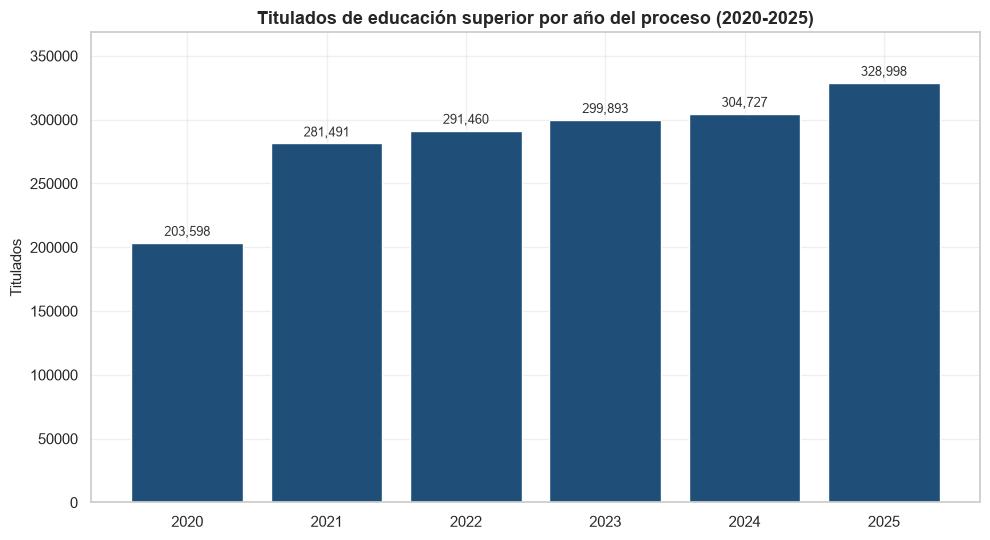

In [13]:
from src import viz

viz.aplicar_estilo()

titulados_anio = df["cat_periodo"].value_counts().sort_index()
fig = viz.barras(
    titulados_anio,
    "Titulados de educación superior por año del proceso (2020-2025)",
    "Titulados",
    horizontal=False,
    formato="{:,.0f}",
    nombre_archivo="f2_1_titulados_por_anio",
)
print(titulados_anio.to_string())

El descenso de 2020 (203.598 registros, un 27,7 % menos que 2021) refleja la
interrupción de la actividad presencial durante la pandemia, que retrasó
exámenes de grado y ceremonias de titulación hacia el año siguiente.

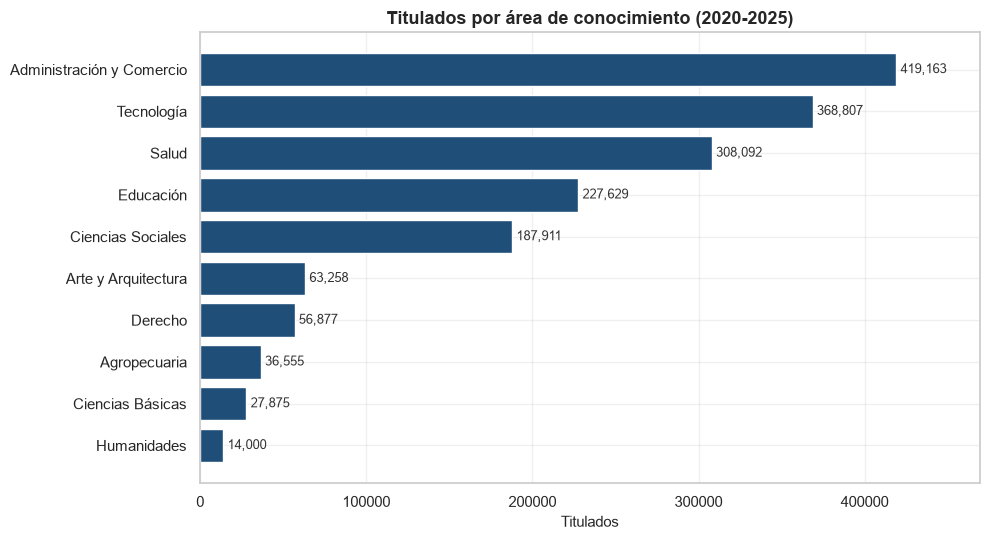

In [14]:
fig = viz.barras(
    df["area_conocimiento"].value_counts(),
    "Titulados por área de conocimiento (2020-2025)",
    "Titulados",
    formato="{:,.0f}",
    nombre_archivo="f2_1_titulados_por_area",
)

Las tres regiones con más titulados concentran el 73.0% del total.


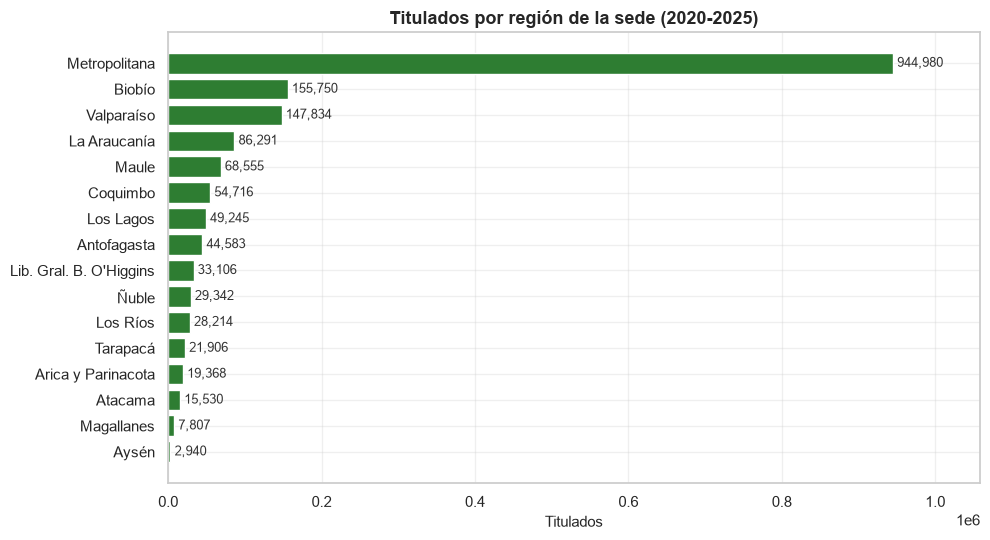

In [15]:
fig = viz.barras(
    df["region_sede"].value_counts(),
    "Titulados por región de la sede (2020-2025)",
    "Titulados",
    color=config.PALETA["acento"],
    formato="{:,.0f}",
    nombre_archivo="f2_1_titulados_por_region",
)
concentracion = 100 * df["region_sede"].value_counts(normalize=True).head(3).sum()
print(f"Las tres regiones con más titulados concentran el {concentracion:.1f}% del total.")

count    1311776.00
mean           7.31
std            2.60
min            1.00
25%            5.00
50%            8.00
75%           10.00
max           24.00


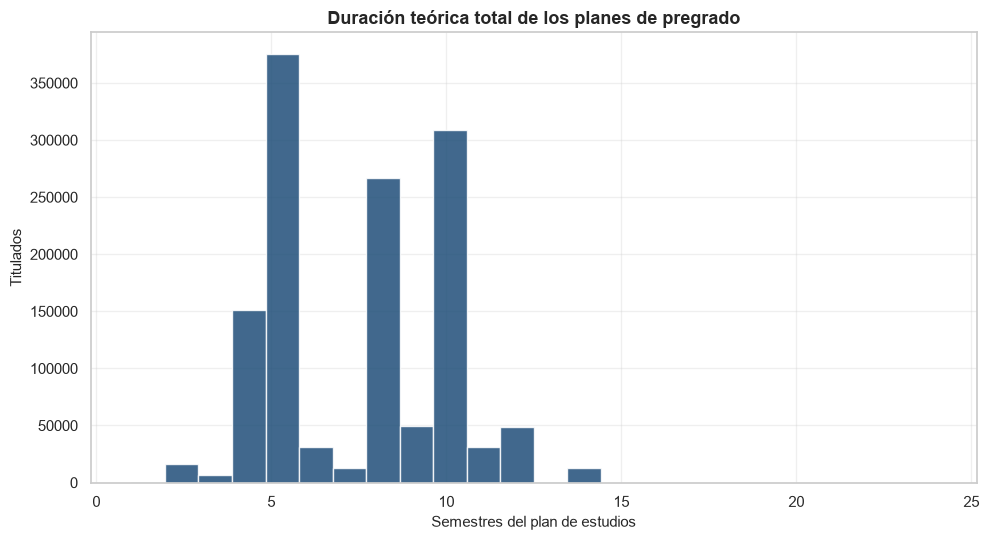

In [16]:
distribucion_dur = df.loc[df["nivel_global"] == "Pregrado", "dur_total_carr"]
fig = viz.histograma(
    distribucion_dur,
    "Duración teórica total de los planes de pregrado",
    "Semestres del plan de estudios",
    bins=24,
    referencia=None,
    nombre_archivo="f2_1_duracion_teorica",
)
print(distribucion_dur.describe().round(2).to_string())

## 7. Inventario de problemas de calidad detectados

Este es el producto principal del notebook: la lista de decisiones que la etapa
de limpieza deberá tomar, con su justificación y su tratamiento previsto.

In [17]:
hallazgos = pd.DataFrame([
    ("H1", "Códigos centinela en año y semestre de ingreso",
     f"{int(df['anio_ing_carr_ori'].isin(config.SENTINELAS_ANIO_INGRESO).sum()):,} registros",
     "Convertir a NA y descartar: sin fecha de inicio no hay duración que medir"),
    ("H2", "Identificador de estudiante vacío",
     f"{int(df['mrun'].isna().sum()):,} registros",
     "Conservar, pero excluir del cotejo de duplicados"),
    ("H3", "Código de carrera vacío",
     f"{int(df['cod_carrera'].isna().sum()):,} registros",
     "Conservar: el análisis usa el nombre y el área, no el código"),
    ("H4", "Duraciones teóricas internamente incoherentes",
     f"{int((df['dur_estudio_carr'] + df['dur_proceso_tit'] != df['dur_total_carr']).sum()):,} registros",
     "Usar dur_total_carr como única referencia teórica"),
    ("H5", "Posgrado y postítulo mezclados con pregrado",
     f"{int((df['nivel_global'] != 'Pregrado').sum()):,} registros",
     "Filtrar: planes no comparables en duración"),
    ("H6", "Categorías de texto con formato heterogéneo",
     "18 columnas categóricas",
     "Normalizar espacios y capitalización antes de agrupar"),
    ("H7", "Ausencia de la variable de duración real",
     "no existe en la fuente",
     "Derivarla desde ingreso y fecha de titulación"),
], columns=["id", "hallazgo", "magnitud", "tratamiento previsto"])

print(hallazgos.to_string(index=False))
hallazgos.to_csv(config.TABLES_DIR / "f2_1_hallazgos_calidad.csv", index=False)
print(f"\nTabla exportada a {config.TABLES_DIR / 'f2_1_hallazgos_calidad.csv'}")

id                                       hallazgo                magnitud                                                      tratamiento previsto
H1 Códigos centinela en año y semestre de ingreso        62,492 registros Convertir a NA y descartar: sin fecha de inicio no hay duración que medir
H2              Identificador de estudiante vacío         3,534 registros                          Conservar, pero excluir del cotejo de duplicados
H3                        Código de carrera vacío        31,629 registros              Conservar: el análisis usa el nombre y el área, no el código
H4  Duraciones teóricas internamente incoherentes       572,146 registros                         Usar dur_total_carr como única referencia teórica
H5    Posgrado y postítulo mezclados con pregrado       398,391 registros                                Filtrar: planes no comparables en duración
H6    Categorías de texto con formato heterogéneo 18 columnas categóricas                     Normalizar espacio

## 8. Cierre del notebook

**Resultado.** Se consolidaron 1.710.167 registros de seis años con coincidencia
exacta contra las cifras oficiales del SIES, se documentó el esquema de 30
variables y se identificaron siete problemas de calidad con su tratamiento
previsto.

**Hallazgo metodológico más relevante.** La base no contiene la duración real de
las trayectorias: solo la duración teórica de los planes. La variable central
del proyecto debe construirse.

> **Continuar en:** `F2/F2_2_Limpieza_Transformacion.ipynb`